4 files
(571, 48)
2025-12-03 20:13:32 2026-09-30 18:42:03


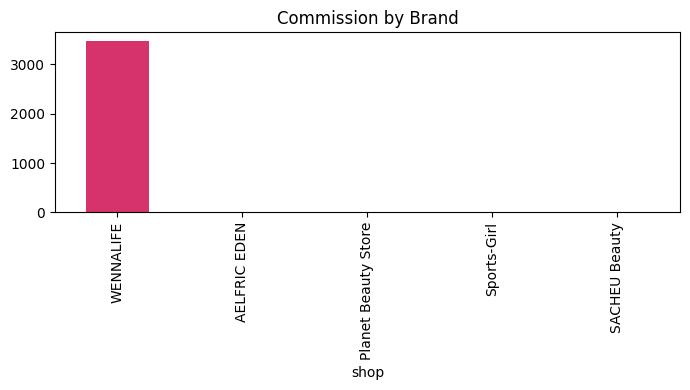

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# 1. Load and combine every export
files = glob.glob("/content/**/affiliate_orders_*.xlsx", recursive=True)
files = [f for f in files if "(1)" not in f]
print(len(files), "files")

df = pd.concat([pd.read_excel(f) for f in files], ignore_index=True)
df = df.drop_duplicates(subset=["Order ID", "SKU ID"])
print(df.shape)   # should say 571 rows

# 2. Keep and rename the columns we need
df = df[["Order date", "Product name", "Shop name", "Price", "Items sold",
         "Items refunded", "Content ID", "Order type", "Order settlement status",
         "GMV", "Total final earned amount"]]
df.columns = ["date", "product", "shop", "price", "units", "refunded",
              "video_id", "order_type", "status", "gmv", "commission"]
df["commission"] = df["commission"].fillna(0)

# 3. Clean
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df["video_id"] = df["video_id"].astype(str)
df["month"] = df["date"].dt.to_period("M").astype(str)

print(df["date"].min(), df["date"].max())

# Chart 1: commission by brand
df.groupby("shop")["commission"].sum().sort_values(ascending=False).head(5) \
  .plot(kind="bar", color="#d6336c", figsize=(7, 4), title="Commission by Brand")
plt.tight_layout(); plt.show()





Wennalife account for nearly all of my earnings, with only a handful of orders from other brands.

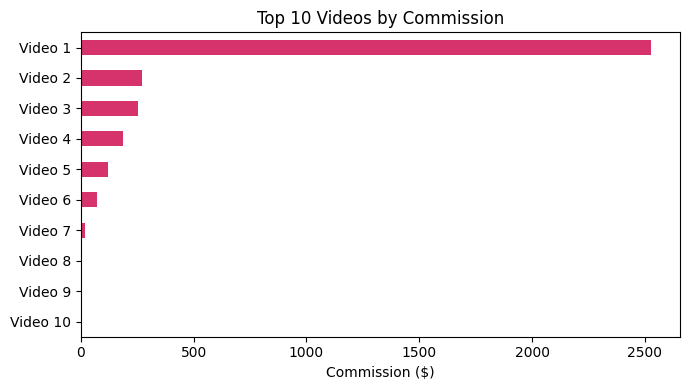

In [7]:
# Chart 2: top 10 videos
top = (df.groupby("video_id")["commission"].sum()
         .sort_values(ascending=False).head(10))
top.index = [f"Video {i}" for i in range(1, len(top) + 1)]

top.plot(kind="barh", color="#d6336c", figsize=(7, 4),
         title="Top 10 Videos by Commission")
plt.gca().invert_yaxis()
plt.xlabel("Commission ($)")
plt.tight_layout(); plt.show()




You see which video is my top performer. It currently holds 1.2M views and it my top paid commission. I would look at the content itself (the way it was filmed, verbiage, lighting, editing) to see what drew people to that video more than other videos. This video earns about 72 percent of my total.

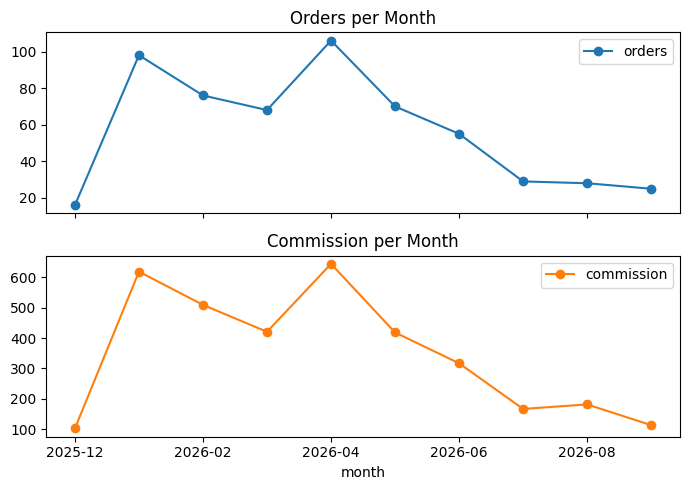

In [3]:
# Chart 3: monthly orders and commission
monthly = df.groupby("month").agg(orders=("video_id", "count"),
                                  commission=("commission", "sum"))
monthly.plot(subplots=True, figsize=(7, 5), marker="o",
             title=["Orders per Month", "Commission per Month"])
plt.tight_layout(); plt.show()


As you can see there has been a decline in sales since April so I would take a look at the reasoning. One possible reasoning is more people spending money on tiktok shop during the holidays, and after where they have more extra money to spend with the holidays being over. This is something to be evaluated to see how to get those sales continously.

In [4]:
print(df.groupby("order_type").agg(orders=("video_id", "count"),
                                   gmv=("gmv", "sum"),
                                   commission=("commission", "sum")))
print(df["status"].value_counts())
print(df.groupby("status")["gmv"].sum())


                 orders       gmv  commission
order_type                                   
Affiliate order     227  20004.99     1402.16
Shop ads order      344  30863.98     2090.93
status
Settled       483
Ineligible     79
Pending         9
Name: count, dtype: int64
status
Ineligible     6975.04
Pending         693.06
Settled       43200.87
Name: gmv, dtype: float64


This shows the shop ads order versus affiliate orders. You see that by running the ads produced more in orders than affiliate orders. Ads orders earn about 60 percent of the total, and affiliate orders about 40 percent.About 14 percent were ineligible and earned 0 dollars.

In [6]:
wenna = df[df["shop"] == "WENNALIFE"]
by_product = (wenna.groupby("product")
                   .agg(orders=("video_id", "count"),
                        commission=("commission", "sum"),
                        avg_price=("price", "mean"))
                   .sort_values("commission", ascending=False))
by_product.index = by_product.index.str[:110]   # shorten the long names
by_product.head(200)


,orders,commission,avg_price
product,,,
WENNALIFE Clip in Hair Extensions Real Human Hair 7pcs 120g-150g 14 Inch to 24 Inch Jet Black to Platinum Blon,314,1965.26,83.973153
WENNALIFE Clip in Hair Extensions Real Human Hair 7pcs 120g-150g 14 Inch to 24 Inch Jet Black to Platinum Blon,70,442.41,77.251000
WENNALIFE Clip in Hair Extensions Real Human Hair 7pcs 120g-150g 14 Inch to 24 Inch Jet Black to Platinum Blon,34,224.73,82.288824
WENNALIFE Clip in Hair Extensions Real Human Hair 7pcs 120g-150g 14 Inch to 24 Inch Jet Black to Platinum Blon,39,203.55,68.824103
WENNALIFE Clip in Hair Extensions Real Human Hair 7pcs 120g-150g 14 Inch to 24 Inch Jet Black to Platinum Blon,30,200.66,92.378000
WENNALIFE Clip in Hair Extensions Real Human Hair 7pcs 120g-150g 14 Inch to 24 Inch Jet Black to Platinum Blon,23,146.28,82.311739
WENNALIFE Clip in Hair Extensions Real Human Hair 7pcs 120g-150g 14 Inch to 24 Inch Jet Black to Platinum Blon,19,120.42,82.187368
WENNALIFE Clip in Hair Extensions Real Human Hair 7pcs 120g-150g 14 Inch to 24 Inch Jet Black to Platinum Blon,11,68.39,75.510909
WENNALIFE Clip in Hair Extensions Real Human Hair 7pcs 120g-150g 14 Inch to 24 Inch Jet Black to Platinum Blon,7,49.52,83.350000


As you see the top selling product is their clip in hair extensions, and I have also built a relationship with the company to promote and run ads on my videos. For that reason I recently started with tape in and butterfly weft to build more sales. Its too new to show in the data yet. Once again I do suggest diversifying so it is not just one company that is gaining me commission.

Recommendation: My income depends heavily on one brand, Wennalife, and on a small number of videos. To reduce that risk, I recommend (1) promoting additional hair-care brands and products that fit my audience, and (2) continuing to create Wennalife content while testing whether other products from the brand, beyond clip-in extensions, sell as well. I'll compare results after a month to see which direction performs better. (3) Study my top video. One video earns most of my commission, so before making more videos, look at what that one did differently (hook, product shown, style) and repeat it.